Purpose
-------
    Assess biogeochemical fields from ACCESS-OM2-WOMBATmid
    
    We use monthly climatologies for assessment (not specific years)
    
    The fields we are assessing are:
        1  - Surface NO3 at the equatorial band    --> World Ocean Atlas 2023 
        2  - Surface Silicic acid globally         --> World Ocean Atlas 2023 
        3  - Surface DOC concentration globally    --> Panaoitis et al. (2025)
        4  - Surface dFe globally                  --> Huang et al. 2022 Frontiers in Marine Science
        5  - Surface Chlorophyll                   --> Sauzede et al. (2016 JGR: Oceans)
        6  - Depth of max Chlorophyll              --> Sauzede et al. (2016 JGR: Oceans)
        7  - Net Primary Production                --> Carbon-based productivity model (CbPM) 
        8  - Primary nutrient limitation (N or Fe) --> Browning & Moore 2023 Nature Communications
        9  - Air-sea CO2 flux (Southern Ocean)     --> Chau et al. (2022)
        10 - Sinking POC fluxes                    --> Mouw et al. (2016)
        11 - Sinking PIC fluxes                    --> Mouw et al. (2016)
        12 - Sinking BSi fluxes                    --> Mouw et al. (2016)
        13 - Fe:C ratios of phytoplankton          --> Twining et al. (2021)
        14 - Si:C ratios of diatoms                --> Twining et al. (2021)
        15 - fraction of microphytoplankton        --> Sathyendranath et al. (2020)
        16 - NH4:DIN - pNH4:pNPP ratio             --> Buchanan et al. (2025)
        
        

## imports

In [3]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe

# statistics package
import skill_metrics as sm

# fit b-values
from scipy.optimize import curve_fit


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


moddir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/"
obsdir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/observations"
os.chdir(obsdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


In [4]:
import warnings
warnings.filterwarnings('ignore')

# start up a dask client

In [5]:
import dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=14, threads_per_worker=1, memory_limit="8GB")
client  = Client(cluster)
client  # shows dashboard link



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 104.31 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34189,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43577,Total threads: 1
Dashboard: /proxy/37983/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:46487,


2026-08-28 18:06:14,712 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0048.gadi.nci.org.au:41004', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.prot

## load data

In [6]:
%%time

os.chdir(obsdir)

bottle_data = xr.open_dataset("sots_monthly_climatology.nc").squeeze()
pco2_data = xr.open_dataset("sots_sofs_pco2_monthly_climatology.nc").squeeze()
chl_data = xr.open_dataset("sots_chl_30m_monthly_climatology.nc").squeeze()
zoo_data = xr.open_dataset("maredat_zoo.nc").squeeze()
bac_data = pd.read_csv("TAN1810_Bacteria_Salp_biomass_converted_mmolC_m3.csv")

### cut out depths > 500 metres
bottle_data = bottle_data.sel(depth=slice(0,500))
zoo_data = zoo_data.sel(DEPTH=slice(0,500))

### Bacterial data
bac_data = bac_data[['Depth water [m]','Bact C [mmol C/m**3] (20 fg C/cell)']]
bac_data = bac_data.sort_values(by='Depth water [m]', ascending=True)
bac_data = bac_data.rename(columns={'Depth water [m]':'depth', 'Bact C [mmol C/m**3] (20 fg C/cell)':'bac'})
bac_data_mean = bac_data.groupby('depth', as_index=False).mean()
bac_data_std = bac_data.groupby('depth', as_index=False).std()
bac_data_mean
bac_data_smooth = pd.DataFrame({
    'depth':bac_data_mean['depth'].values, 
    'mean':bac_data_mean['bac'].values, 
    'std':bac_data_std['bac'].values
})
bac_data

### Argo data
argo_data = xr.open_dataset("ARGO_SOTS.nc").squeeze()
argo_data


CPU times: user 452 ms, sys: 174 ms, total: 626 ms
Wall time: 1.15 s


<xarray.Dataset> Size: 444kB
Dimensions:   (pressure: 1501, month: 12)
Coordinates:
  * pressure  (pressure) int64 12kB 0 1 2 3 4 5 ... 1496 1497 1498 1499 1500
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    POC       (pressure, month) float64 144kB ...
    CHL       (pressure, month) float64 144kB ...
    NO3       (pressure, month) float64 144kB ...

### Annika broken stick b-value functions

In [7]:
%%time

# define spl model (simple power law)
def spl(x, b, cs):
    return (x / x[0]) ** (-b) * cs

# define bpl model (broken power law)
def bpl(x, b1, b2, cd, z_trans):
    return np.where(x < z_trans, (x/z_trans)**(-b1) * cd, (x/z_trans)**(-b2) * cd)

def r2_score_numpy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - ss_res / ss_tot


CPU times: user 15 μs, sys: 21 μs, total: 36 μs
Wall time: 45.3 μs


## Now, load the model output

In [11]:
%%time

vars2d = ['pco2', 'dic_stf', 'mlotst']
vars3d = ['thetao', 'so', 
          'phy', 'dia', 'pchl', 'dchl', 
          'o2', 'no3', 'nh4', 'fe', 'sil',
          'sdet', 'ldet', 'sdet_vmove', 'ldet_vmove',
          'zoo', 'mes', 'lbac', 'obac', 'sbac']

mod = {}
for i in range(1, 101):
    if i % 20 == 0: print(i)
    for vv in vars2d:
        mod[vv + "_%i"%(i)] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull_optimal%i/output009/access-om3.mom6.2d.%s.1day.mean.1909.nc'%(i,vv))[vv].isel(yh=1,xh=1)
    for vv in vars3d:
        mod[vv + "_%i"%(i)] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull_optimal%i/output009/access-om3.mom6.3d.%s.1day.mean.1909.nc'%(i,vv))[vv].isel(yh=1,xh=1)



20
40
60
80
100
CPU times: user 31.5 s, sys: 6.95 s, total: 38.4 s
Wall time: 34.7 s


### Calculate the b values in the upper and lower water column

In [12]:
%%time

def fit_one_experiment_light(exp, sdet, ldet, mlotst, phy, dia, depth_full):

    depth_da = xr.DataArray(
        depth_full,
        dims=["zl"],
        coords={"zl": depth_full}
    )

    poc = (sdet + ldet) * 1.035 * 1e6
    zprod = mlotst
    living = (phy + dia) * 1.035 * 1e6
    D2L = poc / living

    poc_interp = poc.interp(zl=depth_full).transpose("time", "zl")

    mask = (
        (depth_da > zprod) &
        (depth_da < 1000.0)
    ).transpose("time", "zl")

    poc_masked = poc_interp.where(mask)
    depth_2d = depth_da.broadcast_like(poc_masked)
    depth_masked = depth_2d.where(mask)

    time_coord = poc_masked["time"]
    ntime = poc_masked.sizes["time"]

    b_spl      = np.full(ntime, np.nan)
    r2_spl     = np.full(ntime, np.nan)
    b1_bpl     = np.full(ntime, np.nan)
    b2_bpl     = np.full(ntime, np.nan)
    cd_bpl     = np.full(ntime, np.nan)
    ztrans_bpl = np.full(ntime, np.nan)
    r2_bpl     = np.full(ntime, np.nan)

    poc_arr = poc_masked.values
    dep_arr = depth_masked.values
    zprod_arr = zprod.values

    for tt in range(ntime):

        poc_t = poc_arr[tt, :]
        dep_t = dep_arr[tt, :]
        zprod_t = float(zprod_arr[tt])

        valid = np.isfinite(poc_t) & np.isfinite(dep_t) & (poc_t > 0)

        if valid.sum() < 10:
            continue

        poc_fit = poc_t[valid]
        dep_fit = dep_t[valid]

        try:
            popt_spl, _ = curve_fit(
                spl,
                dep_fit,
                poc_fit,
                sigma=0.6 * poc_fit,
                p0=[0.3, 50],
                bounds=([-10, 0], [10, 150]),
                ftol=1e-3,
                maxfev=5000
            )

            y_pred_spl = spl(dep_fit, *popt_spl)

            b_spl[tt] = popt_spl[0]
            r2_spl[tt] = r2_score_numpy(poc_fit, y_pred_spl)

        except Exception as e:
            print(f"EXP {exp}, time {tt}, SPL failed: {repr(e)}")
            pass

        try:
            popt_bpl, _ = curve_fit(
                bpl,
                dep_fit,
                poc_fit,
                sigma=0.6 * poc_fit,
                p0=[0.5, 0.3, 10, zprod_t + 100],
                bounds=(
                    [-10, -10, 0, zprod_t],
                    [10, 10, 150, zprod_t + 300]
                ),
                ftol=1e-3,
                maxfev=5000
            )

            y_pred_bpl = bpl(dep_fit, *popt_bpl)

            b1_bpl[tt]     = popt_bpl[0]
            b2_bpl[tt]     = popt_bpl[1]
            cd_bpl[tt]     = popt_bpl[2]
            ztrans_bpl[tt] = popt_bpl[3]
            r2_bpl[tt]     = r2_score_numpy(poc_fit, y_pred_bpl)

        except Exception as e:
            print(f"EXP {exp}, time {tt}, BPL failed: {repr(e)}")
            pass

    result = xr.Dataset(
        {
            "b_spl":      ("time", b_spl),
            "r2_spl":     ("time", r2_spl),
            "b1_bpl":     ("time", b1_bpl),
            "b2_bpl":     ("time", b2_bpl),
            "cd_bpl":     ("time", cd_bpl),
            "ztrans_bpl": ("time", ztrans_bpl),
            "r2_bpl":     ("time", r2_bpl),
            "D2L":        D2L,
        },
        coords={"time": time_coord}
    )

    return exp, result

CPU times: user 6 μs, sys: 6 μs, total: 12 μs
Wall time: 18.4 μs


In [13]:
%%time

from dask import delayed, compute

depth_full = np.arange(0, 1100, 1)
exps = np.arange(1, 101, 1)

tasks = [
    delayed(fit_one_experiment_light)(
        exp,
        mod["sdet_%i" % exp],
        mod["ldet_%i" % exp],
        mod["mlotst_%i" % exp],
        mod["phy_%i" % exp],
        mod["dia_%i" % exp],
        depth_full
    )
    for exp in exps
]

results = compute(*tasks)

fit_ds = xr.concat(
    [result.expand_dims(exp=[exp]) for exp, result in results],
    dim="exp"
)

fit_ds.to_netcdf(moddir + "/data/poc_attenuation_fits_100exp_optimal.nc")

CPU times: user 27.4 s, sys: 7.56 s, total: 34.9 s
Wall time: 2min 7s


#### Load pre-computed B1 B2 values if necessary

In [9]:
fit_ds = xr.open_dataset(moddir + "/data/poc_attenuation_fits_100exp_optimal.nc")

In [14]:
fit_ds_monthly = fit_ds.groupby("time.month").mean("time", skipna=True)
fit_ds_monthly

<xarray.Dataset> Size: 429kB
Dimensions:     (month: 12, exp: 100, zl: 75)
Coordinates:
  * exp         (exp) int64 800B 1 2 3 4 5 6 7 8 9 ... 93 94 95 96 97 98 99 100
    xh          float64 8B 142.2
    yh          float64 8B -47.25
  * zl          (zl) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.805e+03
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b_spl       (month, exp) float64 10kB 0.6588 0.5949 0.6459 ... 0.5995 0.6234
    r2_spl      (month, exp) float64 10kB 0.883 0.8653 0.838 ... 0.9465 0.9123
    b1_bpl      (month, exp) float64 10kB 0.9026 0.8919 0.9831 ... 0.7381 0.9824
    b2_bpl      (month, exp) float64 10kB 0.4914 0.4411 0.4723 ... 0.5386 0.5125
    cd_bpl      (month, exp) float64 10kB 0.1988 0.1795 0.158 ... 0.3981 0.2294
    ztrans_bpl  (month, exp) float64 10kB 251.9 229.2 232.8 ... 177.4 209.4
    r2_bpl      (month, exp) float64 10kB 0.9832 0.9811 0.9789 ... 0.9893 0.9854
    D2L         (month, exp, zl) float32 360kB 0.2331 0.2433 ... 1.026e+18

In [15]:
%%time

# Monthly coordinate
months = np.arange(1, 13)

# Seasonal b1 cycle
# High in peak summer, low in peak winter.
# For Southern Hemisphere:
# peak summer = January/February-ish
# peak winter = July/August-ish
b1_max = 1.5
b1_min = 0.7

b1_mean = (b1_max + b1_min) / 2
b1_amp  = (b1_max - b1_min) / 2

# Peak at month 1, minimum at month 7
b1 = b1_mean + b1_amp * np.cos(2 * np.pi * (months - 1) / 12)

# Constant b2
b2 = np.full_like(b1, 0.2, dtype=float)

# Difference
b1_minus_b2 = b1 - b2

# Build dataset
ideal_monthly = xr.Dataset(
    {
        "b1_bpl": ("month", b1),
        "b2_bpl": ("month", b2),
        "b1_minus_b2": ("month", b1_minus_b2),
    },
    coords={
        "month": months
    }
)

ideal_monthly

CPU times: user 490 μs, sys: 162 μs, total: 652 μs
Wall time: 640 μs


<xarray.Dataset> Size: 384B
Dimensions:      (month: 12)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b1_bpl       (month) float64 96B 1.5 1.446 1.3 1.1 0.9 ... 0.9 1.1 1.3 1.446
    b2_bpl       (month) float64 96B 0.2 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2 0.2
    b1_minus_b2  (month) float64 96B 1.3 1.246 1.1 0.9 0.7 ... 0.7 0.9 1.1 1.246

### Conver model data to observations grid

In [16]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

for i in range(1, 101):
    if i % 20 == 0: print(i)
    for vv in np.concatenate((vars2d, vars3d)):
        mod[vv + "_%i_obsgrid"%(i)] = mod[vv + "_%i"%(i)].groupby("time.month").mean("time")
        if vv in vars3d:
            mod[vv + "_%i_obsgrid"%(i)] = mod[vv + "_%i_obsgrid"%(i)].interp(zl=target_depth)
            
mod['phy_1_obsgrid']

20
40
60
80
100
CPU times: user 44.6 s, sys: 7.44 s, total: 52.1 s
Wall time: 45.3 s


<xarray.DataArray 'phy' (month: 12, depth: 26)> Size: 2kB
array([[           nan, 1.88830896e-06, 1.39079589e-06, 6.91660963e-07,
        1.41689614e-07, 6.66475220e-08, 5.10159144e-08, 4.61380097e-08,
        4.37383253e-08, 4.23272347e-08, 4.13183242e-08, 3.99340845e-08,
        3.64267560e-08, 2.99715217e-08, 2.02342871e-08, 1.03229059e-08,
        3.30450557e-09, 1.08755489e-09, 2.71495971e-10, 5.81973982e-11,
        1.58845027e-11, 3.63401616e-12, 9.03532840e-13, 3.25682344e-13,
        6.36390100e-14, 3.25235750e-14],
       [           nan, 1.63673736e-06, 1.46176414e-06, 1.27645489e-06,
        3.10123692e-07, 4.66040342e-08, 3.15578785e-08, 2.78491203e-08,
        2.61853214e-08, 2.52245137e-08, 2.45244444e-08, 2.35772493e-08,
        2.14673506e-08, 1.77567066e-08, 1.22332249e-08, 6.50702403e-09,
        2.35063904e-09, 8.19398002e-10, 2.33016672e-10, 5.31791416e-11,
        1.58965975e-11, 3.67785346e-12, 9.32812901e-13, 3.29934029e-13,
        5.86166028e-14, 2.97470327e-14],
       [           nan, 1.46939928e-06, 1.29067013e-06, 1.14168920e-06,
        5.21261881e-07, 5.08105083e-08, 2.06579092e-08, 1.71820528e-08,
        1.60088773e-08, 1.53622858e-08, 1.48857579e-08, 1.42464714e-08,
        1.29404081e-08, 1.07319342e-08, 7.49928850e-09, 4.12914475e-09,
        1.63186004e-09, 5.98743954e-10, 1.88244598e-10, 4.56380209e-11,
        1.47482359e-11, 3.50029974e-12, 9.32597448e-13, 3.27640096e-13,
...
        5.39840528e-07, 4.75246907e-07, 4.41407085e-07, 4.17174576e-07,
        3.96548968e-07, 3.62981913e-07, 3.34473166e-07, 3.14347434e-07,
        2.53715639e-07, 1.54242523e-07, 4.88381390e-08, 1.68383142e-08,
        1.54594413e-09, 4.12159946e-10, 4.60589860e-11, 1.02684585e-11,
        3.05697599e-12, 8.70216299e-13, 3.09235811e-13, 1.15871316e-13,
        2.66063907e-14, 1.34622847e-14],
       [           nan, 1.53415189e-06, 1.15667228e-06, 6.98652082e-07,
        3.26835345e-07, 1.95126759e-07, 1.69822595e-07, 1.58016143e-07,
        1.51631296e-07, 1.47837113e-07, 1.45139760e-07, 1.41237293e-07,
        1.21378502e-07, 8.30315581e-08, 3.15383860e-08, 1.22137364e-08,
        1.88683237e-09, 5.27869578e-10, 7.61553846e-11, 1.48022730e-11,
        3.44017126e-12, 8.67403361e-13, 2.60018228e-13, 9.70389662e-14,
        2.19548143e-14, 1.11422642e-14],
       [           nan, 1.87963661e-06, 1.24665736e-06, 7.58400392e-07,
        2.05319255e-07, 1.07408075e-07, 8.86011477e-08, 8.17921287e-08,
        7.81970891e-08, 7.60652729e-08, 7.45095487e-08, 7.19450742e-08,
        6.26498774e-08, 4.49986431e-08, 1.98153186e-08, 8.37548556e-09,
        1.73904772e-09, 5.15546488e-10, 9.44057210e-11, 1.84958973e-11,
        4.31790321e-12, 9.93491491e-13, 2.50498607e-13, 9.12075163e-14,
        1.86286632e-14, 9.45646792e-15]])
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    zl       (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Attributes:
    units:          mol/kg
    long_name:      Phytoplankton
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

## Assess the model fit to the observations

In [17]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

bac_xr = (
    bac_data_smooth
    .set_index("depth")
    .to_xarray()
)

bac_data_obsgrid = bac_xr.interp(depth=target_depth)
bac_data_obsgrid

CPU times: user 3.94 ms, sys: 1.19 ms, total: 5.12 ms
Wall time: 4.86 ms


<xarray.Dataset> Size: 624B
Dimensions:  (depth: 26)
Coordinates:
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Data variables:
    mean     (depth) float64 208B nan 2.496 2.26 1.984 1.192 ... nan nan nan nan
    std      (depth) float64 208B nan 1.018 0.9538 0.396 ... nan nan nan nan

In [18]:
%%time

target_depth = bottle_data.depth
argo_data_obsgrid = argo_data.interp(pressure=target_depth)
argo_data_obsgrid = argo_data_obsgrid.where(argo_data_obsgrid.depth > 10.0, other=np.nan)


CPU times: user 24.7 ms, sys: 0 ns, total: 24.7 ms
Wall time: 32.4 ms


In [19]:
%%time

print("put all the observations into a dictionary for iteration")
obsdata = {
    'pco2': pco2_data['pco2_sw'],
    'fgco2': pco2_data['co2_flux_mol_m2_y1'] * (-1),
    'nh4': bottle_data['ammonia'], 
    #'no3': bottle_data['nitrate'], 
    'no3': argo_data_obsgrid['NO3'], 
    'sil': bottle_data['silicate'], 
    'dfe': bottle_data['dFe'], 
    #'poc': bottle_data['POC'], 
    'poc': argo_data_obsgrid['POC']*0.5/12/3.0, 
    'bac': bac_data_obsgrid['mean'], 
    'micro': zoo_data['micro_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    'meso': zoo_data['meso_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    #'chl_bottle': bottle_data['chlorophyll_total_mv'],
    'chl_bottle': argo_data_obsgrid['CHL'],
    'chl_mooring': chl_data['chlorophyll'],
    'b1mb2': ideal_monthly['b1_minus_b2'],
    'D2L300mD2L50': ideal_monthly['b1_minus_b2']*0.5+2.0
    }


put all the observations into a dictionary for iteration
CPU times: user 65.9 ms, sys: 22.2 ms, total: 88.1 ms
Wall time: 61.6 ms


In [20]:
target_vars = np.array(list(obsdata.keys()))

for i in range(1, 101):
    if i % 20 == 0: print(i)
    mod[target_vars[0]+"_%i"%(i)] = mod['pco2_%i_obsgrid'%(i)]
    mod[target_vars[1]+"_%i"%(i)] = mod['dic_stf_%i_obsgrid'%(i)]*365*86400
    mod[target_vars[2]+"_%i"%(i)] = mod['nh4_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[3]+"_%i"%(i)] = mod['no3_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[4]+"_%i"%(i)] = mod['sil_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[5]+"_%i"%(i)] = mod['fe_%i_obsgrid'%(i)]*1e9*1.035
    mod[target_vars[6]+"_%i"%(i)] = (mod['sdet_%i_obsgrid'%(i)] + mod['ldet_%i_obsgrid'%(i)])*1e6*1.035
    mod[target_vars[7]+"_%i"%(i)] = (mod['lbac_%i_obsgrid'%(i)] + mod['obac_%i_obsgrid'%(i)] + mod['sbac_%i_obsgrid'%(i)]).sel(month=11,method='nearest')*1e6*1.035
    mod[target_vars[8]+"_%i"%(i)] = (mod['zoo_%i_obsgrid'%(i)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[9]+"_%i"%(i)] = (mod['mes_%i_obsgrid'%(i)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[10]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['dchl_%i_obsgrid'%(i)])*1e6*1.035*12
    mod[target_vars[11]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['dchl_%i_obsgrid'%(i)]).sel(depth=30.0,method='nearest')*1e6*1.035*12
    mod[target_vars[12]+"_%i"%(i)] = (fit_ds_monthly['b1_bpl'] - fit_ds_monthly['b2_bpl']).sel(exp=i)
    mod[target_vars[13]+"_%i"%(i)] = (fit_ds_monthly['D2L'].sel(zl=300, method='nearest') -
                                      fit_ds_monthly['D2L'].sel(zl=50, method='nearest')).sel(exp=i)




20
40
60
80
100


In [21]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

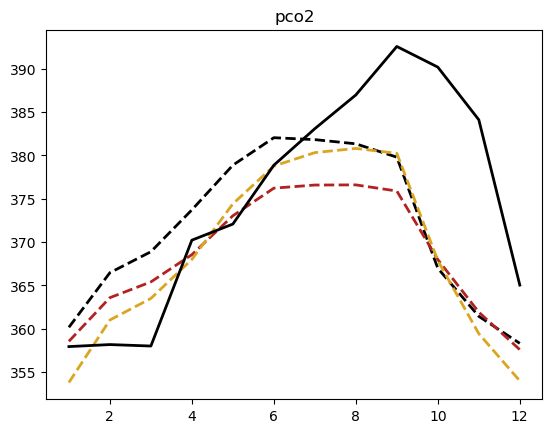

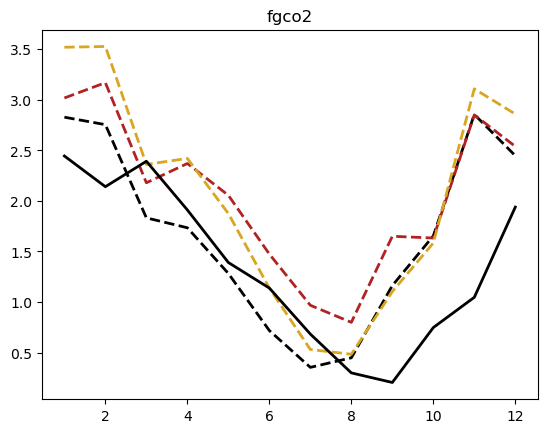

In [54]:
vv = target_vars[0]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k', zorder=3, linewidth=2)
#for i in np.arange(351,352,1):
#    plt.plot(target_month, mod[vv+"_%i"%(i)])
plt.plot(target_month, mod[vv+"_%i"%(2)], 'k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], 'firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], 'goldenrod', linewidth=2, linestyle='--')

vv = target_vars[1]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k', zorder=3, linewidth=2)
#for i in np.arange(351,352,1):
#    plt.plot(target_month, mod[vv+"_%i"%(i)])
plt.plot(target_month, mod[vv+"_%i"%(2)], 'k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], 'firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], 'goldenrod', linewidth=2, linestyle='--')

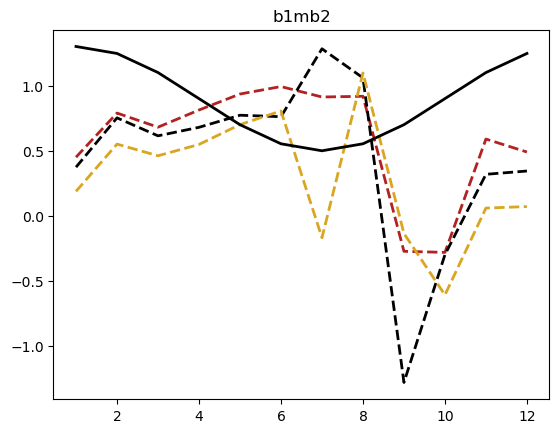

In [55]:
vv = target_vars[12]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k', zorder=3, linewidth=2)
#for i in np.arange(351,352,1):
#    plt.plot(target_month, mod[vv+"_%i"%(i)])
plt.plot(target_month, mod[vv+"_%i"%(2)], 'firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], 'k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], 'goldenrod', linewidth=2, linestyle='--')

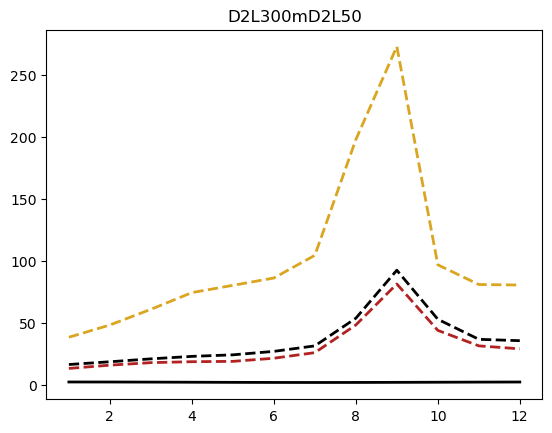

In [56]:
vv = target_vars[13]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k', zorder=3, linewidth=2)
#for i in np.arange(351,352,1):
#    plt.plot(target_month, mod[vv+"_%i"%(i)])
plt.plot(target_month, mod[vv+"_%i"%(2)], 'firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], 'k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], 'goldenrod', linewidth=2, linestyle='--')

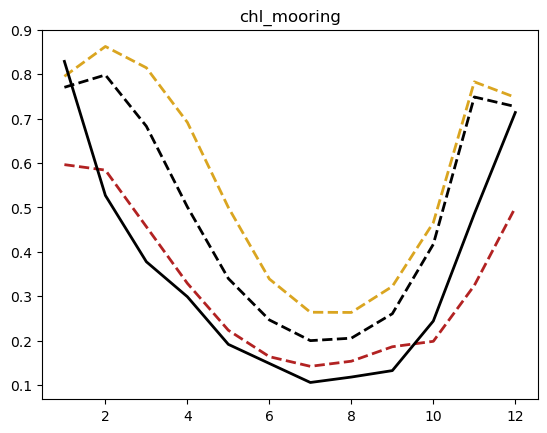

In [57]:
vv = target_vars[11]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k', zorder=3, linewidth=2)
#for i in np.arange(301,401,1):
#    plt.plot(target_month, mod[vv+"_%i"%(i)])
plt.plot(target_month, mod[vv+"_%i"%(2)], 'k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], 'firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], 'goldenrod', linewidth=2, linestyle='--')


In [27]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

nh4
no3
sil
dfe
poc
chl_bottle


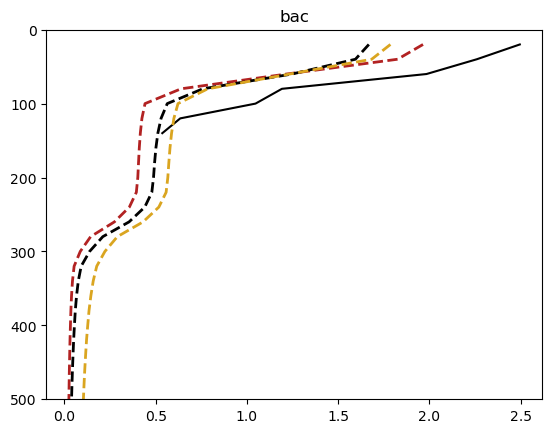

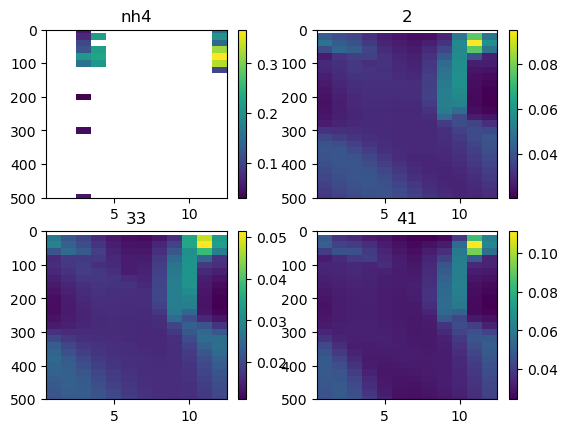

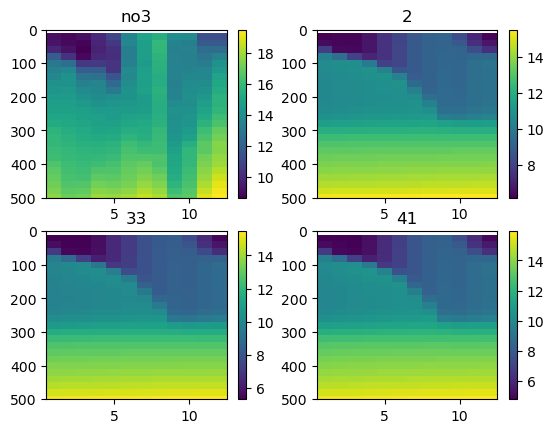

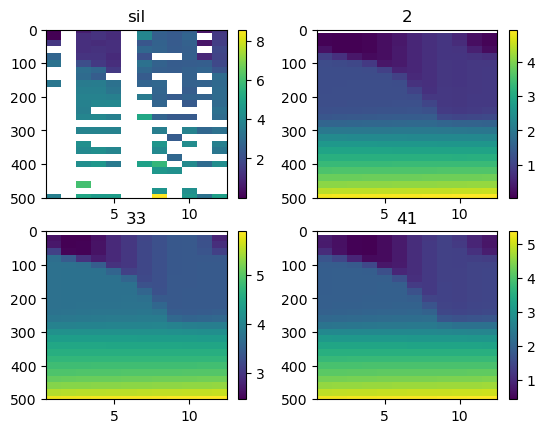

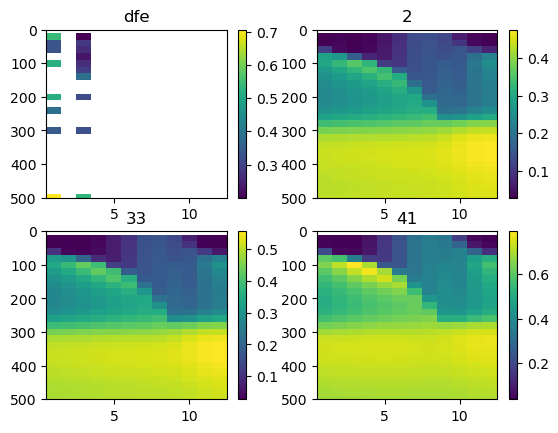

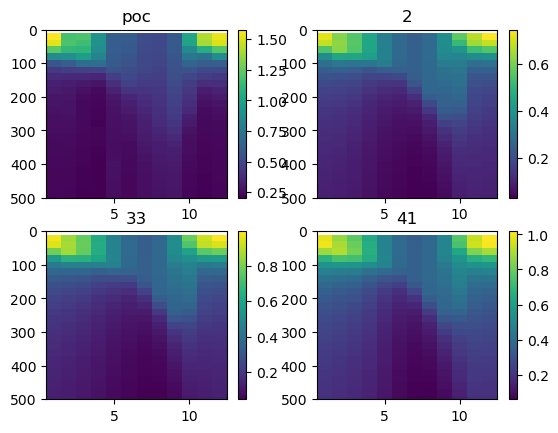

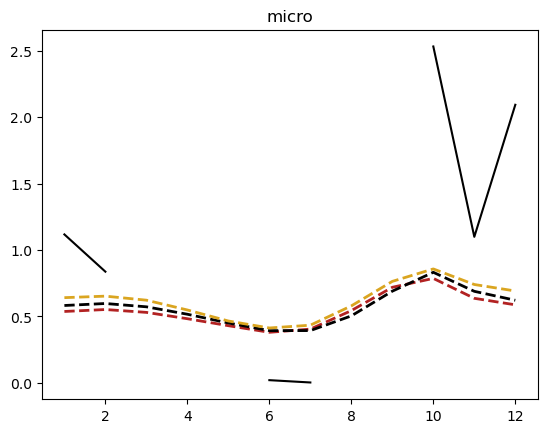

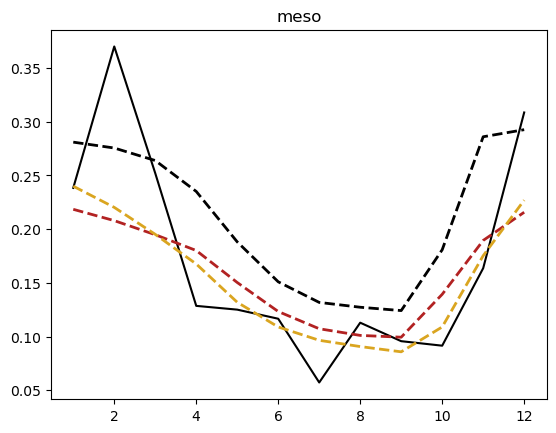

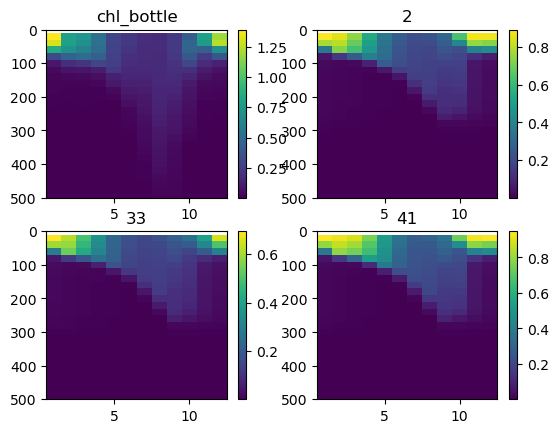

In [58]:
i = 2

vv = target_vars[7]
plt.figure()
plt.title(vv)
plt.plot(obsdata[vv], target_depth, 'k')
plt.plot(mod[vv+"_%i"%(i)], target_depth, color='firebrick', linewidth=2, linestyle='--')
plt.plot(mod[vv+"_%i"%(33)], target_depth, color='k', linewidth=2, linestyle='--')
plt.plot(mod[vv+"_%i"%(41)], target_depth, color='goldenrod', linewidth=2, linestyle='--')
plt.ylim(500,0)

vv = target_vars[2]
print(vv)
plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0]); ax2 = plt.subplot(gs[1]); ax3 = plt.subplot(gs[2]); ax4 = plt.subplot(gs[3]);
ax1.set_title(vv); ax2.set_title("%i"%(i)); ax3.set_title("33"); ax4.set_title("41")
p1 = ax1.pcolormesh(target_month, target_depth, obsdata[vv])
p2 = ax2.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
p3 = ax3.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(33)].T)
p4 = ax4.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(41)].T)
plt.colorbar(p1, ax=ax1); plt.colorbar(p2, ax=ax2); plt.colorbar(p3, ax=ax3); plt.colorbar(p4, ax=ax4);
ax1.set_ylim(500,0); ax2.set_ylim(500,0); ax3.set_ylim(500,0); ax4.set_ylim(500,0);

vv = target_vars[3]
print(vv)
plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0]); ax2 = plt.subplot(gs[1]); ax3 = plt.subplot(gs[2]); ax4 = plt.subplot(gs[3]);
ax1.set_title(vv); ax2.set_title("%i"%(i)); ax3.set_title("33"); ax4.set_title("41")
p1 = ax1.pcolormesh(target_month, target_depth, obsdata[vv])
p2 = ax2.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
p3 = ax3.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(33)].T)
p4 = ax4.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(41)].T)
plt.colorbar(p1, ax=ax1); plt.colorbar(p2, ax=ax2); plt.colorbar(p3, ax=ax3); plt.colorbar(p4, ax=ax4);
ax1.set_ylim(500,0); ax2.set_ylim(500,0); ax3.set_ylim(500,0); ax4.set_ylim(500,0);

vv = target_vars[4]
print(vv)
plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0]); ax2 = plt.subplot(gs[1]); ax3 = plt.subplot(gs[2]); ax4 = plt.subplot(gs[3]);
ax1.set_title(vv); ax2.set_title("%i"%(i)); ax3.set_title("33"); ax4.set_title("41")
p1 = ax1.pcolormesh(target_month, target_depth, obsdata[vv])
p2 = ax2.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
p3 = ax3.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(33)].T)
p4 = ax4.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(41)].T)
plt.colorbar(p1, ax=ax1); plt.colorbar(p2, ax=ax2); plt.colorbar(p3, ax=ax3); plt.colorbar(p4, ax=ax4);
ax1.set_ylim(500,0); ax2.set_ylim(500,0); ax3.set_ylim(500,0); ax4.set_ylim(500,0);


vv = target_vars[5]
print(vv)
plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0]); ax2 = plt.subplot(gs[1]); ax3 = plt.subplot(gs[2]); ax4 = plt.subplot(gs[3]);
ax1.set_title(vv); ax2.set_title("%i"%(i)); ax3.set_title("33"); ax4.set_title("41")
p1 = ax1.pcolormesh(target_month, target_depth, obsdata[vv])
p2 = ax2.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
p3 = ax3.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(33)].T)
p4 = ax4.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(41)].T)
plt.colorbar(p1, ax=ax1); plt.colorbar(p2, ax=ax2); plt.colorbar(p3, ax=ax3); plt.colorbar(p4, ax=ax4);
ax1.set_ylim(500,0); ax2.set_ylim(500,0); ax3.set_ylim(500,0); ax4.set_ylim(500,0);


vv = target_vars[6]
print(vv)
plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0]); ax2 = plt.subplot(gs[1]); ax3 = plt.subplot(gs[2]); ax4 = plt.subplot(gs[3]);
ax1.set_title(vv); ax2.set_title("%i"%(i)); ax3.set_title("33"); ax4.set_title("41")
p1 = ax1.pcolormesh(target_month, target_depth, obsdata[vv])
p2 = ax2.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
p3 = ax3.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(33)].T)
p4 = ax4.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(41)].T)
plt.colorbar(p1, ax=ax1); plt.colorbar(p2, ax=ax2); plt.colorbar(p3, ax=ax3); plt.colorbar(p4, ax=ax4);
ax1.set_ylim(500,0); ax2.set_ylim(500,0); ax3.set_ylim(500,0); ax4.set_ylim(500,0);



vv = target_vars[8]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)], color='firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], color='k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], color='goldenrod', linewidth=2, linestyle='--')

vv = target_vars[9]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)], color='firebrick', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(33)], color='k', linewidth=2, linestyle='--')
plt.plot(target_month, mod[vv+"_%i"%(41)], color='goldenrod', linewidth=2, linestyle='--')

vv = target_vars[10]
print(vv)
plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0]); ax2 = plt.subplot(gs[1]); ax3 = plt.subplot(gs[2]); ax4 = plt.subplot(gs[3]);
ax1.set_title(vv); ax2.set_title("%i"%(i)); ax3.set_title("33"); ax4.set_title("41")
p1 = ax1.pcolormesh(target_month, target_depth, obsdata[vv])
p2 = ax2.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
p3 = ax3.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(33)].T)
p4 = ax4.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(41)].T)
plt.colorbar(p1, ax=ax1); plt.colorbar(p2, ax=ax2); plt.colorbar(p3, ax=ax3); plt.colorbar(p4, ax=ax4);
ax1.set_ylim(500,0); ax2.set_ylim(500,0); ax3.set_ylim(500,0); ax4.set_ylim(500,0);


In [30]:

print("create the dictionary for holding the statistics")
stats = {}


for exp in np.arange(1,101):
    for vv in target_vars:
        if (vv == "pco2") or (vv == 'fgco2') or (vv == "chl_mooring") \
        or (vv == "bac") or (vv == "micro") or (vv == 'meso') \
        or (vv == "b1mb2") or (vv == 'D2L300mD2L50'):
            predicted = mod[vv+"_%i"%(exp)].values
            observed = obsdata[vv].values
        else:
            predicted = mod[vv+"_%i"%(exp)].values.ravel()
            observed = obsdata[vv].values.ravel()
        
        # remove NaNs
        pred_good = ~np.isnan(predicted)
        obs_good = ~np.isnan(observed)
        good = pred_good * obs_good
        predicted = predicted[good]
        observed = observed[good]
        if np.std(predicted) == 0.0:
            predicted[-1] = predicted[-1]+1e-10

        if exp == 1:
            stats[vv+'_sdev'] = sm.taylor_statistics(predicted, observed)['sdev']
            stats[vv+'_nsdev'] = (sm.taylor_statistics(predicted, observed)['sdev']/sm.taylor_statistics(predicted, observed)['sdev'][0]).tolist()
            stats[vv+'_crmsd'] = sm.taylor_statistics(predicted, observed)['crmsd']
            stats[vv+'_rmse'] = np.array([0.0, sm.rmsd(predicted, observed)]).tolist()
            stats[vv+'_nrmse'] = np.array([0.0, sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed))]).tolist()
            stats[vv+'_ccoef'] = sm.taylor_statistics(predicted, observed)['ccoef'].tolist()
            stats[vv+'_bias'] = np.array([0.0, np.mean(predicted - observed)]).tolist()
        else:
            stats[vv+'_sdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1])
            stats[vv+'_nsdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1]/sm.taylor_statistics(predicted, observed)['sdev'][0])
            stats[vv+'_crmsd'].append(sm.taylor_statistics(predicted, observed)['crmsd'][1])
            stats[vv+'_ccoef'].append(sm.taylor_statistics(predicted, observed)['ccoef'][1])
            stats[vv+'_bias'].append(np.mean(predicted - observed))
            stats[vv+'_rmse'].append(sm.rmsd(predicted, observed))
            stats[vv+'_nrmse'].append(sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed)))
            


create the dictionary for holding the statistics


## save the statistics

In [31]:

os.chdir(moddir + "/data/")
os.getcwd()


'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data'

In [32]:
df_stats = pd.DataFrame(stats)
df_stats


,pco2_sdev,pco2_nsdev,pco2_crmsd,pco2_rmse,pco2_nrmse,pco2_ccoef,pco2_bias,fgco2_sdev,fgco2_nsdev,fgco2_crmsd,...,b1mb2_nrmse,b1mb2_ccoef,b1mb2_bias,D2L300mD2L50_sdev,D2L300mD2L50_nsdev,D2L300mD2L50_crmsd,D2L300mD2L50_rmse,D2L300mD2L50_nrmse,D2L300mD2L50_ccoef,D2L300mD2L50_bias
0,12.370366,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.759892,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.141421,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,8.186093,0.661750,9.156635,9.850089,0.809365,0.672464,-3.630469,0.863460,1.136294,0.547677,...,1.716717,-0.473559,-0.216625,108.794128,769.290660,108.884076,159.233925,1.808662,-0.635630,116.188213
2,8.646483,0.698967,10.939859,11.374911,0.994624,0.505362,-3.115780,0.870482,1.145534,0.664185,...,1.547705,-0.197695,-0.314840,18.550467,131.171607,18.604553,33.942230,1.660838,-0.379191,28.389182
3,7.974788,0.644669,10.459475,14.359903,0.955569,0.543444,-9.839013,0.816981,1.075128,0.615985,...,1.745881,-0.524049,-0.058817,8109.239746,57340.984147,8109.322925,9130.527691,1.780975,-0.585936,4195.881535
4,10.880988,0.879601,10.570083,11.364099,0.901983,0.593213,-4.173259,1.142017,1.502868,0.818105,...,1.758662,-0.546447,-0.241822,59.562233,421.168588,59.644706,96.995312,1.778984,-0.582392,76.489213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,10.498328,0.848668,11.841446,14.008104,1.026023,0.473638,-7.483791,1.074917,1.414567,0.860819,...,1.731103,-0.498358,-0.144929,211.529129,1495.736816,211.624878,287.853408,1.831313,-0.676854,195.126864
97,7.035298,0.568722,11.243333,11.573036,1.060886,0.437260,-2.742740,0.718077,0.944973,0.664823,...,1.732353,-0.500524,-0.212618,1315.779419,9303.965497,1315.878599,1628.436356,1.844610,-0.701293,959.306224
98,6.857545,0.554353,11.756441,11.938779,1.127404,0.364480,-2.078589,0.661168,0.870082,0.674667,...,1.743772,-0.520371,-0.156775,195.937317,1385.486055,196.034882,277.544103,1.838292,-0.689659,196.471516
99,9.521554,0.769707,10.340876,10.717348,0.915952,0.580516,-2.815639,0.985076,1.296337,0.681595,...,1.669643,-0.393854,-0.448045,71.323921,504.336283,71.416706,129.932934,1.819609,-0.655489,108.545943


In [33]:
os.getcwd()

'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data'

In [34]:
print("Saving the global skill")

cols_to_drop = [column for column in df_stats.columns if '_rmse' not in column]
df_rmse = df_stats.drop(columns=cols_to_drop).drop(0)
df_rmse['sum_rmse'] = df_rmse.sum(axis=1)
df_rmse.to_excel('optimal100_RMSE.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_nrmse' not in column]
df_nrmse = df_stats.drop(columns=cols_to_drop).drop(0)
df_nrmse['sum_nrmse'] = df_nrmse.sum(axis=1)
df_nrmse.to_excel('optimal100_NRMSE.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_sdev' not in column]
df_sdev = df_stats.drop(columns=cols_to_drop).drop(0)
df_sdev['sum_sdev'] = df_sdev.sum(axis=1)
df_sdev.to_excel('optimal100_SDEV.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_nsdev' not in column]
df_nsdev = df_stats.drop(columns=cols_to_drop).drop(0)
df_nsdev['sum_nsdev'] = df_nsdev.sum(axis=1)
df_nsdev.to_excel('optimal100_NSDEV.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_bias' not in column]
df_bias = df_stats.drop(columns=cols_to_drop).drop(0)
df_bias['sum_bias'] = df_bias.sum(axis=1)
df_bias.to_excel('optimal100_BIAS.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_ccoef' not in column]
df_ccoef = df_stats.drop(columns=cols_to_drop).drop(0)
df_ccoef['sum_ccoef'] = df_ccoef.sum(axis=1)
df_ccoef.to_excel('optimal100_CCOEF.xlsx', index=False)




Saving the global skill


## make a Taylor Diagram of the results

In [35]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

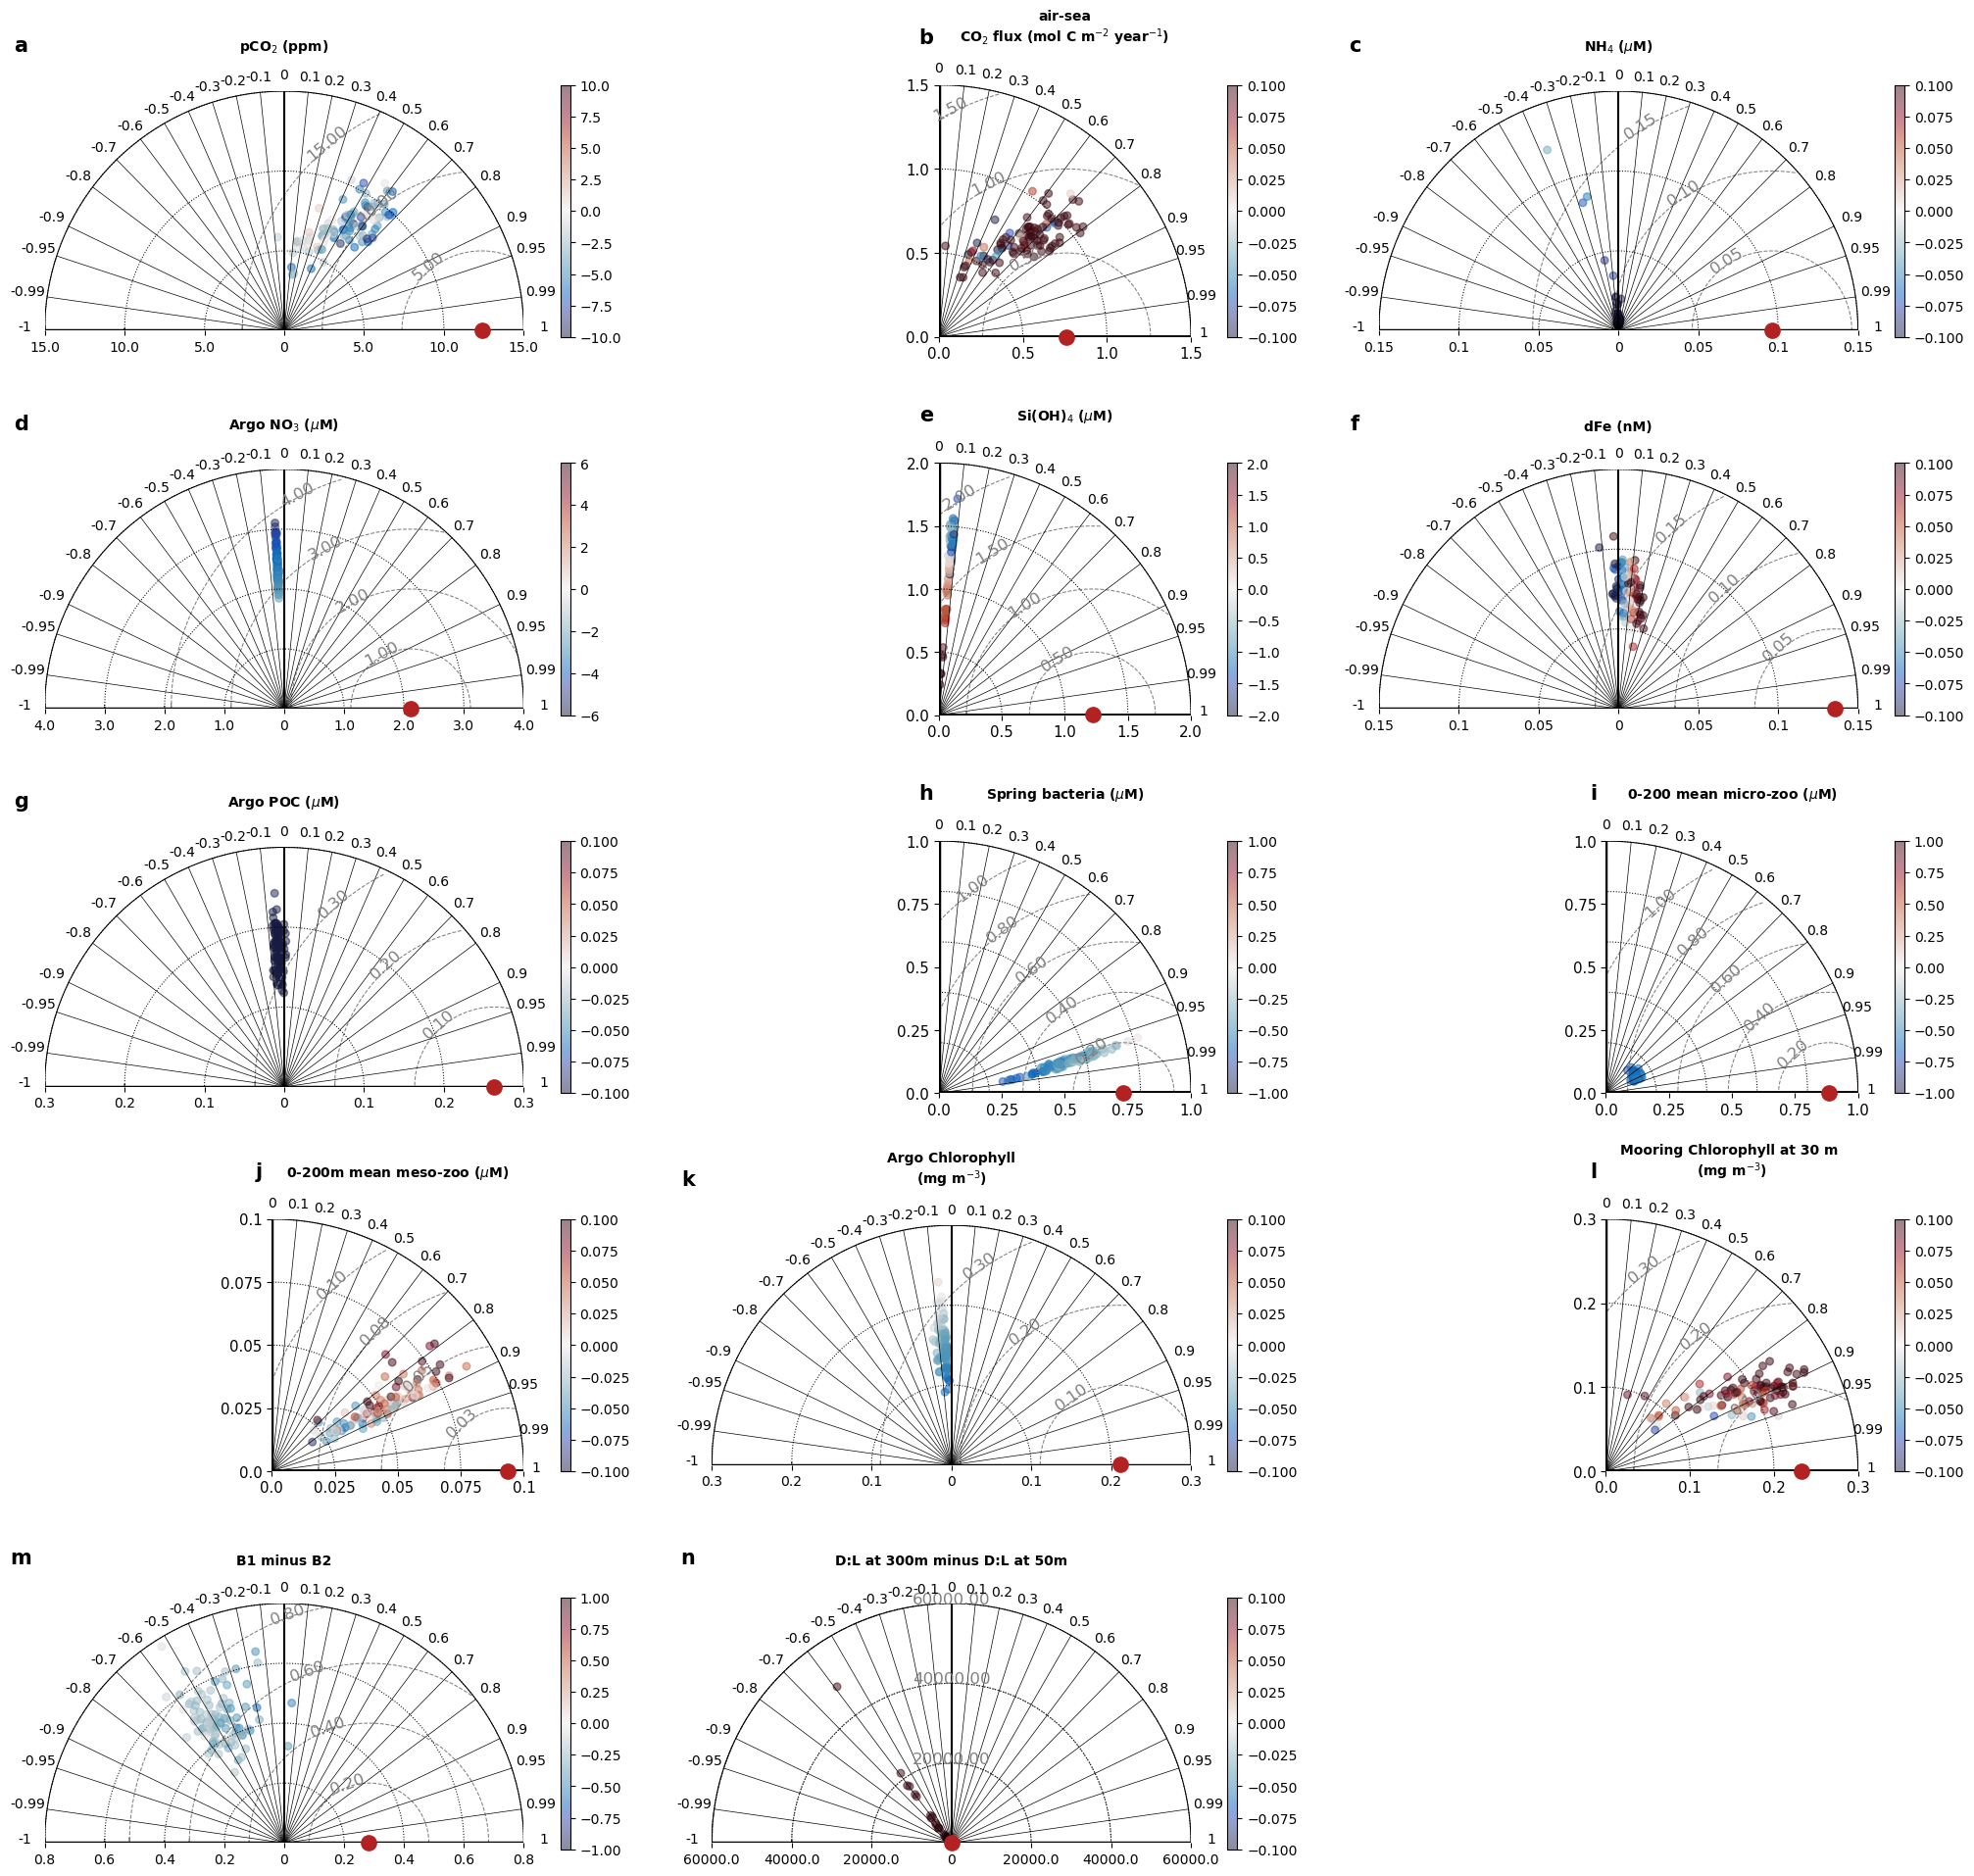

In [36]:

fslab = 15
fstic = 13

labs = ['pCO$_2$ (ppm)', \
        'air-sea\nCO$_2$ flux (mol C m$^{-2}$ year$^{-1}$)', \
        'NH$_4$ ($\mu$M)', \
        'Argo NO$_3$ ($\mu$M)', \
        'Si(OH)$_4$ ($\mu$M)', \
        'dFe (nM)', \
        'Argo POC ($\mu$M)', \
        'Spring bacteria ($\mu$M)', \
        '0-200 mean micro-zoo ($\mu$M)', \
        '0-200m mean meso-zoo ($\mu$M)', \
        'Argo Chlorophyll\n(mg m$^{-3}$)', \
        'Mooring Chlorophyll at 30 m \n(mg m$^{-3}$)', \
        'B1 minus B2', \
        'D:L at 300m minus D:L at 50m'
        ] 
letter = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']

fig = plt.figure(figsize=(22,20))
gs = GridSpec(5, 3)

for vi,vv in enumerate(target_vars):
    ax = plt.subplot(gs[vi])

    vmin = 0 - np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmax = 0 + np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmin = 0 - np.abs(np.round(np.min(stats[vv+'_bias'])))
    vmax = 0 + np.abs(np.round(np.min(stats[vv+'_bias'])))
    statss = stats

    
    sm.taylor_diagram(np.array(statss[vv+'_sdev']), np.array(statss[vv+'_crmsd']), np.array(statss[vv+'_ccoef']), alpha=0.1, 
                      MarkerDisplayed='colorBar', cmapzdata=np.array(statss[vv+'_bias']), locationColorBar='EastOutside', titleColorBar=' ', 
                      cmap=lighten(cmo.balance,0.5), cmap_marker='o', markerSize=15, cmap_vmax=vmax, cmap_vmin=vmin, 
                      colRMS='grey', styleRMS='--', widthRMS=0.75, showlabelsRMS='on', titleRMS='off', rmsLabelFormat='0:.2f',
                      colSTD='k', styleSTD=':', widthSTD=0.75, showlabelsSTD='off', titleSTD='off', 
                      colCOR='k', styleCOR='-', widthCOR=0.5, showlabelsCOR='on', titleCOR='off', 
                      markerOBS='o', colOBS='firebrick')

    plt.text(0.5,1.15, labs[vi], transform=ax.transAxes, va='bottom', ha='center', fontweight='bold')
    plt.text(-0.05,1.15, letter[vi], fontweight='bold', fontsize=fslab, ha='center', va='bottom', transform=ax.transAxes)


plt.subplots_adjust(hspace=0.5, wspace=0.1, right=0.95, left=0.05, bottom=0.05, top=0.95)



os.chdir("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures")
fig.savefig("assess_performance_TaylorDiagram_optimal100.png", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_optimal100.pdf", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_optimal100_transparent.png", dpi=300, transparent=True)


### Load the data and find out what the best experiments are

In [37]:
%%time

datadir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data"

df_CCOEF = pd.read_excel(datadir + "/optimal100_CCOEF.xlsx")

df_NRMSE = pd.read_excel(datadir + "/optimal100_NRMSE.xlsx")

df_SDEV = pd.read_excel(datadir + "/optimal100_SDEV.xlsx")

df_BIAS = pd.read_excel(datadir + "/optimal100_BIAS.xlsx")


CPU times: user 1.79 s, sys: 697 ms, total: 2.48 s
Wall time: 6.17 s


In [43]:
df_NRMSE.sort_values(by="sum_nrmse", ascending=True)


,pco2_nrmse,fgco2_nrmse,nh4_nrmse,no3_nrmse,sil_nrmse,dfe_nrmse,poc_nrmse,bac_nrmse,micro_nrmse,meso_nrmse,chl_bottle_nrmse,chl_mooring_nrmse,b1mb2_nrmse,D2L300mD2L50_nrmse,sum_nrmse
40,0.804237,0.623227,1.385371,1.444130,1.367906,1.283891,1.408327,0.249335,0.436476,0.490281,1.455584,0.582231,1.547724,1.767558,14.846278
32,0.843478,0.685560,1.406126,1.446974,1.362248,1.354423,1.444381,0.199876,0.454275,0.624672,1.444162,0.416242,1.515668,1.664454,14.862538
0,0.809365,0.663926,1.392509,1.446616,1.363269,1.221734,1.449482,0.194833,0.416434,0.581854,1.444666,0.411523,1.716717,1.808662,14.921589
90,0.895023,0.732994,1.417225,1.447525,1.354907,1.332661,1.453964,0.225426,0.405028,0.620585,1.449330,0.342238,1.637240,1.686096,15.000242
78,0.812705,0.660347,1.463922,1.447620,1.362605,1.351853,1.459545,0.210080,0.499062,0.657248,1.454187,0.425866,1.375784,1.825246,15.006070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,1.212268,1.050200,1.401134,1.447263,1.356256,1.435763,1.447803,0.255150,0.594319,0.471511,1.501179,0.777327,1.774499,1.840210,16.564883
51,1.134435,0.949511,1.433086,1.445488,1.351922,1.434271,1.480629,0.262707,0.682807,0.488973,1.513473,1.207209,1.386499,1.843367,16.614377
22,1.331677,1.148132,1.410903,1.448850,1.358623,1.495592,1.478499,0.262887,0.472839,0.517296,1.500092,0.664403,1.700589,1.831395,16.621775
21,1.304489,1.121824,1.455554,1.450592,1.360750,1.406951,1.456114,0.257083,0.629567,0.501623,1.494835,0.817482,1.783793,1.828282,16.868939


In [44]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

In [45]:
df_cost = (1.0 - df_CCOEF.values) * df_NRMSE.values
df_cost = pd.DataFrame(
    df_cost[:,0:-1],
    index=df_CCOEF.index,
    columns=target_vars
)
df_cost

,pco2,fgco2,nh4,no3,sil,dfe,poc,bac,micro,meso,chl_bottle,chl_mooring,b1mb2,D2L300mD2L50
0,0.265096,0.146329,1.350093,1.513664,1.266821,0.911800,1.522680,0.003698,0.036108,0.098494,1.507551,0.034846,2.529684,2.958301
1,0.491979,0.261068,1.327520,1.516430,1.246616,1.287680,1.513690,0.009643,0.041045,0.097115,1.522032,0.043450,1.853679,2.290613
2,0.436271,0.235839,1.197451,1.522390,1.274218,1.272613,1.548835,0.006789,0.036429,0.185091,1.522342,0.050759,2.660808,2.824512
3,0.366915,0.234116,1.458951,1.511662,1.245169,0.928411,1.463522,0.005972,0.036028,0.069902,1.515434,0.052913,2.719678,2.815051
4,1.122807,0.762806,1.350244,1.516303,1.244657,1.484190,1.592285,0.008878,0.247925,0.068890,1.704541,0.564000,2.311244,2.913988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.540060,0.348215,1.430882,1.526091,1.246859,1.450064,1.504016,0.006910,0.031848,0.272221,1.513160,0.037601,2.593811,3.070844
96,0.597003,0.362345,1.669146,1.520897,1.242966,1.291233,1.482260,0.007455,0.113127,0.056326,1.705250,0.296583,2.599438,3.138223
97,0.716487,0.417391,1.339305,1.513944,1.245400,1.269258,1.482933,0.007498,0.077315,0.083377,1.521644,0.036159,2.651180,3.106086
98,0.384228,0.205554,1.335506,1.504289,1.258658,1.212492,1.389511,0.007225,0.069249,0.051832,1.568590,0.087029,2.327238,3.012343


In [49]:
df_cost['sum'] = df_cost.sum(axis=1)
df_cost.sort_values(by='sum',ascending=True)[0:20]

,pco2,fgco2,nh4,no3,sil,dfe,poc,bac,micro,meso,chl_bottle,chl_mooring,b1mb2,D2L300mD2L50,sum
32,0.300048,0.161104,1.390090,1.514788,1.263975,1.242317,1.506660,0.003993,0.046873,0.121878,1.505975,0.036058,1.740935,2.305607,52.561208
40,0.260089,0.121035,1.329438,1.505876,1.279791,1.058167,1.396626,0.007750,0.041577,0.058926,1.541992,0.098686,1.853749,2.761155,53.259425
1,0.491979,0.261068,1.327520,1.516430,1.246616,1.287680,1.513690,0.009643,0.041045,0.097115,1.522032,0.043450,1.853679,2.290613,54.010241
78,0.268392,0.143975,1.568643,1.516819,1.264969,1.235260,1.554615,0.004636,0.062149,0.141958,1.537556,0.038618,1.302030,3.040422,54.720163
90,0.358486,0.196911,1.423267,1.516520,1.243651,1.183394,1.536848,0.005728,0.033222,0.119501,1.522200,0.020043,2.194354,2.396719,55.003378
11,0.260355,0.131734,1.365296,1.513063,1.292536,1.039675,1.476784,0.007263,0.048501,0.058293,1.564219,0.092337,2.230136,2.827699,55.631557
43,0.267838,0.171650,1.538502,1.506676,1.269169,1.107346,1.507614,0.002796,0.049938,0.090557,1.463591,0.047423,2.480322,2.407554,55.643906
44,0.330274,0.202549,1.330939,1.509255,1.270753,0.979817,1.524996,0.003877,0.046368,0.085525,1.508522,0.039596,2.360585,2.779524,55.890322
7,0.492985,0.266657,1.239102,1.519529,1.247959,1.184924,1.553834,0.006451,0.036877,0.054175,1.550751,0.061515,2.254605,2.562831,56.128782
18,0.391408,0.230157,1.360162,1.508249,1.272053,0.829904,1.492546,0.003623,0.055953,0.073950,1.520895,0.059946,2.322691,3.018606,56.560570


In [51]:
df_subset = df_cost.drop(columns=['no3','nh4','sil','chl_bottle','b1mb2'])
df_subset['sum'] = df_subset.sum(axis=1)
df_subset.sort_values(by='sum', ascending=True)[0:20]

,pco2,fgco2,dfe,poc,bac,micro,meso,chl_mooring,D2L300mD2L50,sum
32,0.300048,0.161104,1.242317,1.506660,0.003993,0.046873,0.121878,0.036058,2.305607,58.285747
40,0.260089,0.121035,1.058167,1.396626,0.007750,0.041577,0.058926,0.098686,2.761155,59.063436
1,0.491979,0.261068,1.287680,1.513690,0.009643,0.041045,0.097115,0.043450,2.290613,60.046525
90,0.358486,0.196911,1.183394,1.536848,0.005728,0.033222,0.119501,0.020043,2.396719,60.854230
78,0.268392,0.143975,1.235260,1.554615,0.004636,0.062149,0.141958,0.038618,3.040422,61.210186
43,0.267838,0.171650,1.107346,1.507614,0.002796,0.049938,0.090557,0.047423,2.407554,61.296623
11,0.260355,0.131734,1.039675,1.476784,0.007263,0.048501,0.058293,0.092337,2.827699,61.574196
44,0.330274,0.202549,0.979817,1.524996,0.003877,0.046368,0.085525,0.039596,2.779524,61.882848
7,0.492985,0.266657,1.184924,1.553834,0.006451,0.036877,0.054175,0.061515,2.562831,62.349031
0,0.265096,0.146329,0.911800,1.522680,0.003698,0.036108,0.098494,0.034846,2.958301,62.558011
